# Level 0 electro-thermal battery twin

Built with [Vicena](https://vicena.ai). This notebook executes a transparent 1RC Thevenin cell model with Coulomb-counted SOC and a lumped thermal balance. Parameters are illustrative and not calibrated to a specific cell.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0,str(Path('..')/'src'))
import numpy as np
import matplotlib.pyplot as plt
from battery_twin import simulate_profile, CellParameters
out=Path('../outputs'); out.mkdir(exist_ok=True)

In [2]:
t=np.arange(0,3601,1.0)
current=np.select([t<900,t<1200,t<2400,t<2700],[3.0,0.0,1.5,0.0],default=4.5)
r=simulate_profile(t,current,ambient_c=25,soc0=0.95)
print('Assumptions: 3 Ah cell, 1RC Thevenin ECM, positive current is discharge')
print(f'Final SOC: {r.soc.iloc[-1]:.4f}')
print(f'Minimum terminal voltage: {r.voltage_v.min():.4f} V')
print(f'Maximum cell temperature: {r.temperature_c.max():.3f} C')
print(f'Energy delivered: {(r.voltage_v*r.current_a).clip(lower=0).sum()/3600:.3f} Wh')
r.to_csv(out/'level0_profile.csv',index=False)

Assumptions: 3 Ah cell, 1RC Thevenin ECM, positive current is discharge
Final SOC: 0.1623
Minimum terminal voltage: 2.9781 V
Maximum cell temperature: 26.841 C
Energy delivered: 8.304 Wh


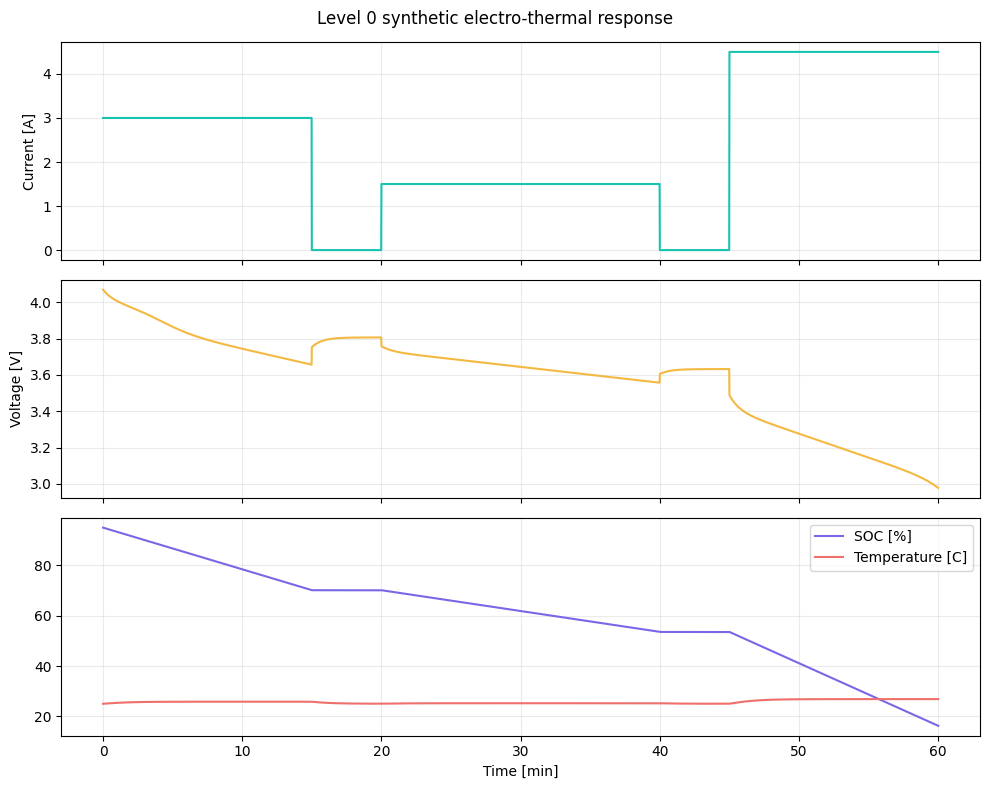

In [3]:
fig,ax=plt.subplots(3,1,figsize=(10,8),sharex=True)
ax[0].plot(r.time_s/60,r.current_a,color='#19c3b1'); ax[0].set_ylabel('Current [A]')
ax[1].plot(r.time_s/60,r.voltage_v,color='#f4b942'); ax[1].set_ylabel('Voltage [V]')
ax[2].plot(r.time_s/60,r.soc*100,label='SOC [%]',color='#7868e6'); ax[2].plot(r.time_s/60,r.temperature_c,label='Temperature [C]',color='#ef6f6c'); ax[2].legend(); ax[2].set_xlabel('Time [min]')
for a in ax: a.grid(alpha=.25)
fig.suptitle('Level 0 synthetic electro-thermal response'); fig.tight_layout(); fig.savefig(out/'level0_electrothermal.png',dpi=180); plt.show()